In [1]:
import jax.numpy as jnp
import neural_tangents as nt
from sklearn.model_selection import train_test_split
from jax.nn import one_hot
from jax import random, jit
import matplotlib.pyplot as plt
from neural_tangents import stax
from tqdm import tqdm

from utils.classificationDataGeneration import make_classification_dataset, demo_2d_examples, plot_2d_kde, plot_train_test_split

Demo: K=16, overlap=0.1 -> sigma=0.05825


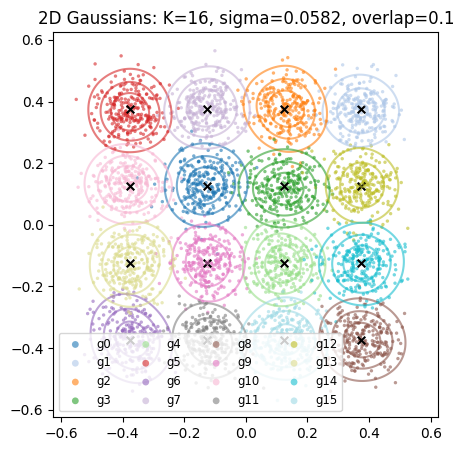

Classification Task: C=2


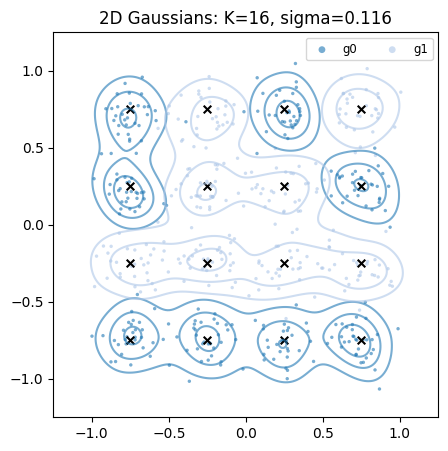

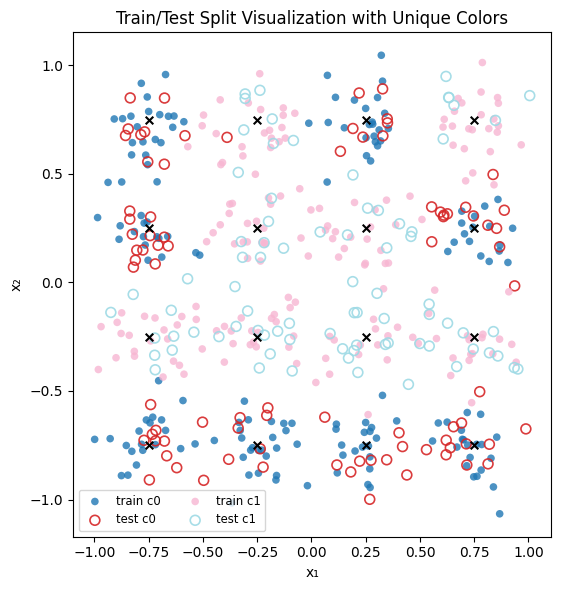

In [2]:
# Visualize demos (this will show 4 plots for Ks=(9,16) and overlaps=(0.2, 0.6))
demo_2d_examples(M=1.0, Ks=(16,), overlaps=(0.1,), samples_per_gaussian=250, random_state=42)

# Create a classification dataset
C=2  # Number of classes
N=2 # Number of dimensions
P=500 # Number of total points

ds = make_classification_dataset(N=N, K=16, M=2.0, C=C, P=P, overlap=0.1, random_state=1)
X, y = ds['X'], ds['y']
assignment = ds['assignment']  # dict gaussian_idx -> class
centers = ds['centers']
sigma = ds['sigma']
print(f"Classification Task: C={C}")
_ = plot_2d_kde(centers, sigma, X, y)

# Let's train test split the data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
plot_train_test_split(x_train, y_train, x_test, y_test, centers, title="Train/Test Split Visualization with Unique Colors")

# Transform to jax arrays
x_train, x_test, y_trian, y_test = jnp.array(x_train), jnp.array(x_test), jnp.array(y_train), jnp.array(y_test)
y_train = one_hot(y_train, C).astype(jnp.float32)   # (n_train, C)
y_test  = one_hot(y_test,  C).astype(jnp.float32)   # (n_test, C)

In [3]:
def compute_empirical_ntk(apply_fn, params, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Create a function that computes the empirical NTK
    ntk_fn = nt.empirical_ntk_fn(apply_fn, trace_axes=(), vmap_axes=0, implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES)
   
    # Compute the kernel matrices
    ntk_train_train = ntk_fn(x_train, x_train, params)
    ntk_test_train  = ntk_fn(x_test, x_train, params)
    ntk_test_test   = ntk_fn(x_test, x_test, params)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Compute the kernel matrices, diagonal
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')#, diagonal_outputs=False)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

In [4]:
# Parameters
widths = [2**i for i in range(16)][3:]
n_seeds = 10
C = 2  # Number of classes
key = random.PRNGKey(0)

# Regularization values
regs = [1e-3]

# Storage
results = {}  # Dictionary: reg -> dict(widths, mse, acc, mse_inf, acc_inf)

# Loop over regularizations
for reg in regs:
    print(f"Processing regularization = {reg}")
    
    errors_avg = []
    errors_std = []
    accuracies_avg = []
    accuracies_std = []
    
    Ks_train_train_dict = {}
    Ks_test_train_dict = {}

    # Loop over widths
    pbar = tqdm(widths, desc=f"Reg={reg}", leave=False)
    for width in pbar:
        pbar.set_description(f"Reg={reg}, Width={width}")
        
        mse_list = []
        acc_list = []
        keys = random.split(key, n_seeds)
        
        # Build network
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
        )
        apply_fn = jit(apply_fn)
        kernel_fn = jit(kernel_fn, static_argnames=('get'))
        
        for subkey in keys:
            _, params = init_fn(subkey, x_train.shape)
            
            # Compute empirical NTK
            ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
            K_train_train = ntk_dict["train_train"]
            K_test_train = ntk_dict["test_train"]
            
            # Gradient descent predictor
            predict_fn = nt.predict.gradient_descent_mse(
                K_train_train, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=True
            )
            
            fx_train_0 = apply_fn(params, x_train)
            fx_test_0 = apply_fn(params, x_test)
            
            _, preds_test = predict_fn(
                t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                k_test_train=K_test_train
            )
            
            mse_list.append(float(jnp.mean((preds_test - y_test)**2)))
            pred_labels = jnp.argmax(preds_test, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_list.append(float(jnp.mean(pred_labels == true_labels)))
        
        # Average over seeds
        errors_avg.append(jnp.mean(jnp.array(mse_list)))
        errors_std.append(jnp.std(jnp.array(mse_list)))
        accuracies_avg.append(jnp.mean(jnp.array(acc_list)))
        accuracies_std.append(jnp.std(jnp.array(acc_list)))
        
        Ks_train_train_dict[width] = K_train_train
        Ks_test_train_dict[width] = K_test_train

    # Infinite-width NTK
    ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
    K_train_train_inf = ntk_dict_inf["train_train"]
    K_test_train_inf = ntk_dict_inf["test_train"]
    
    K_train_train_inf = jnp.stack([jnp.stack([K_train_train_inf if i==j else jnp.zeros_like(K_train_train_inf)
                                               for j in range(C)], axis=-1)
                                    for i in range(C)], axis=-2)

    K_test_train_inf = jnp.stack([jnp.stack([K_test_train_inf if i==j else jnp.zeros_like(K_test_train_inf)
                                             for j in range(C)], axis=-1)
                                  for i in range(C)], axis=-2)

    predict_fn_inf = nt.predict.gradient_descent_mse(
        K_train_train_inf, y_train,
        diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=True
    )
    
    fx_train_0_inf = jnp.zeros_like(y_train)
    fx_test_0_inf = jnp.zeros_like(y_test)
    
    _, preds_test_inf = predict_fn_inf(
        t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
        k_test_train=K_test_train_inf
    )
    
    mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
    pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
    acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
    
    # Save results
    results[reg] = {
        "widths": widths,
        "mse_avg": errors_avg,
        "mse_std": errors_std,
        "acc_avg": accuracies_avg,
        "acc_std": accuracies_std,
        "mse_inf": mse_inf,
        "acc_inf": acc_inf
    }

Processing regularization = 0.001


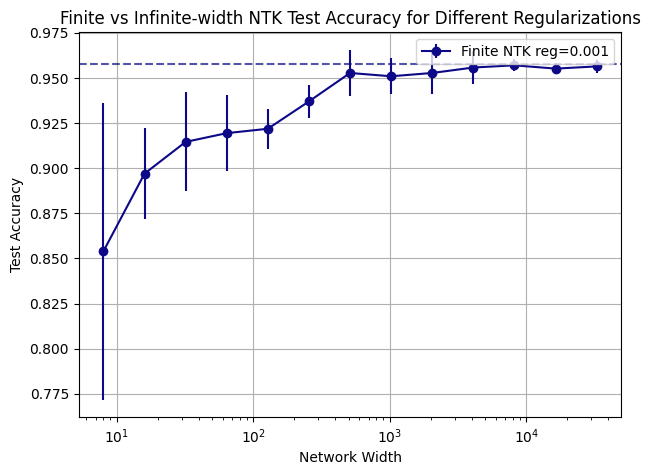

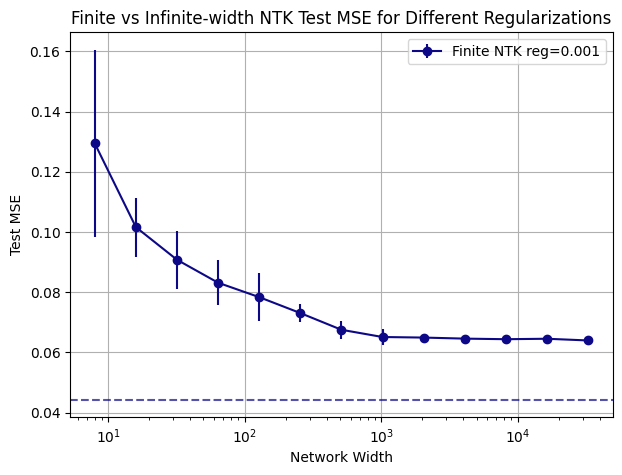

In [5]:
# Plot Test Accuracy vs Width for all regs
plt.figure(figsize=(7,5))
colors = plt.cm.plasma(jnp.linspace(0,1,len(regs)))
for i, reg in enumerate(regs):
    plt.errorbar(results[reg]["widths"], results[reg]["acc_avg"], yerr=results[reg]["acc_std"],
                 marker='o', color=colors[i], label=f'Finite NTK reg={reg}')
    plt.axhline(y=results[reg]["acc_inf"], color=colors[i], linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width')
plt.ylabel('Test Accuracy')
plt.title('Finite vs Infinite-width NTK Test Accuracy for Different Regularizations')
plt.legend()
plt.grid(True)
plt.show()

# Plot Test MSE vs Width for all regs
plt.figure(figsize=(7,5))
for i, reg in enumerate(regs):
    plt.errorbar(results[reg]["widths"], results[reg]["mse_avg"], yerr=results[reg]["mse_std"],
                 marker='o', color=colors[i], label=f'Finite NTK reg={reg}')
    plt.axhline(y=results[reg]["mse_inf"], color=colors[i], linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width')
plt.ylabel('Test MSE')
plt.title('Finite vs Infinite-width NTK Test MSE for Different Regularizations')
plt.legend()
plt.grid(True)
plt.show()


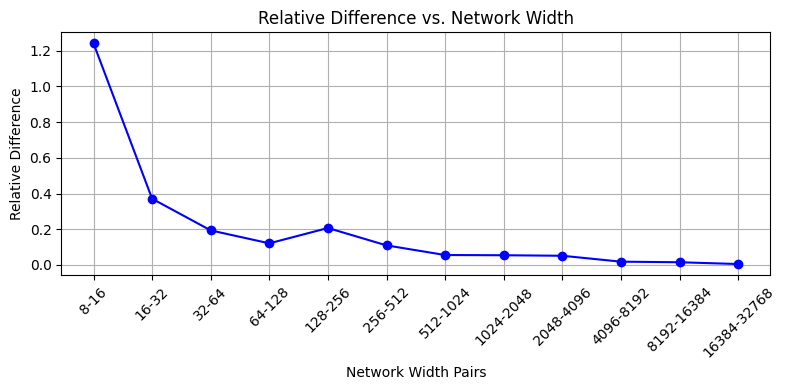

In [6]:
rels = []

for a, b in zip(widths[:-1], widths[1:]):
    rels.append(float(jnp.linalg.norm(Ks_train_train_dict[a] - Ks_train_train_dict[b]) / (jnp.linalg.norm(Ks_train_train_dict[b]) + 1e-12)))
    # print(f"{a} -> {b}: rel_diff={rels[-1]:.3e}")

# Labels for consecutive width pairs
xs = [f"{a}-{b}" for a, b in zip(widths[:-1], widths[1:])]

plt.figure(figsize=(8,4))
plt.plot(xs, rels, marker="o", color="blue")
plt.xlabel('Network Width Pairs')
plt.ylabel('Relative Difference')
plt.title('Relative Difference vs. Network Width')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

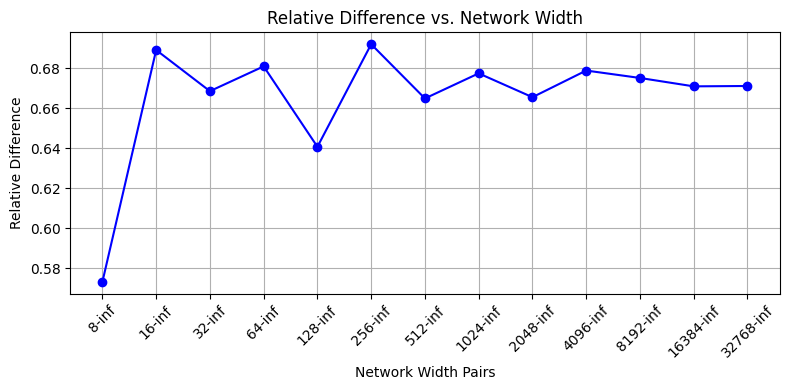

In [7]:
K_ref=K_train_train_inf
rels = []

for a in widths:
    rels.append(float(jnp.linalg.norm(Ks_train_train_dict[a] - K_ref) / (jnp.linalg.norm(K_ref) + 1e-12)))
    # print(f"{a} -> {b}: rel_diff={rels[-1]:.3e}")

# Labels for consecutive width pairs
xs = [f"{a}-inf" for a in widths]

plt.figure(figsize=(8,4))
plt.plot(xs, rels, marker="o", color="blue")
plt.xlabel('Network Width Pairs')
plt.ylabel('Relative Difference')
plt.title('Relative Difference vs. Network Width')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

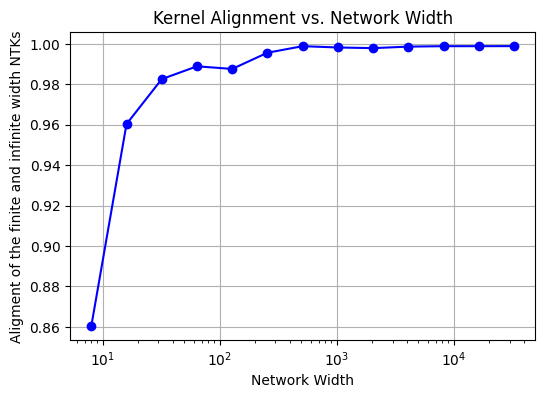

In [10]:
def align(A,B):
    return float((A * B).sum() / ((jnp.linalg.norm(A) * jnp.linalg.norm(B)) + 1e-12))

aligns=[]
for w in widths:
    aligns.append(align(Ks_train_train_dict[w], K_ref))

plt.figure(figsize=(6,4))
plt.plot(widths, aligns, marker="o", color="blue")
plt.xscale('log')
plt.xlabel('Network Width')
plt.ylabel('Aligment of the finite and infinite width NTKs')
plt.title('Kernel Alignment vs. Network Width')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Correlation(K_finite, K_inf)')

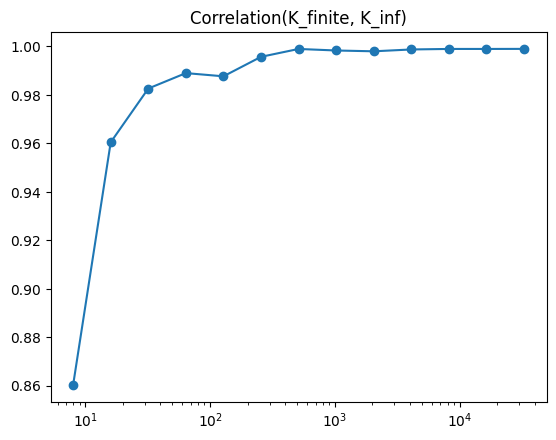

In [11]:
def kernel_corr(K1, K2):
    return jnp.corrcoef(K1.ravel(), K2.ravel())[0,1]

corrs = [kernel_corr(Ks_train_train_dict[a], K_ref) for a in widths]
plt.plot(widths, corrs, marker='o')
plt.xscale('log')
plt.title("Correlation(K_finite, K_inf)")


In [12]:
def normalize(K):
    return K / jnp.linalg.norm(K)

rels_normed = [float(jnp.linalg.norm(normalize(Ks_train_train_dict[a]) - normalize(K_ref))) 
               for a in widths]


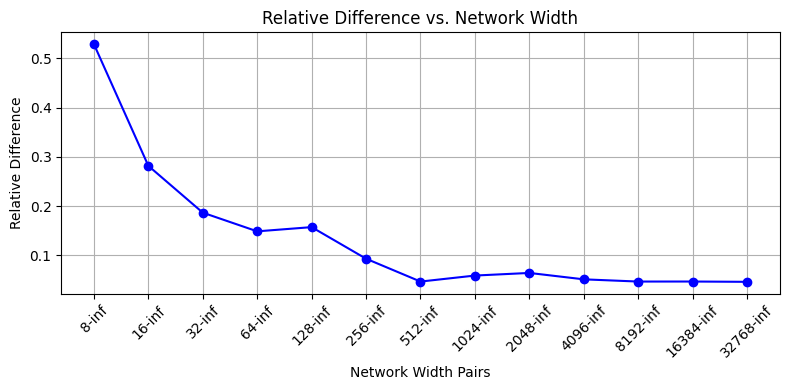

In [14]:
plt.figure(figsize=(8,4))
plt.plot(xs, rels_normed, marker="o", color="blue")
plt.xlabel('Network Width Pairs')
plt.ylabel('Relative Difference')
plt.title('Relative Difference vs. Network Width')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

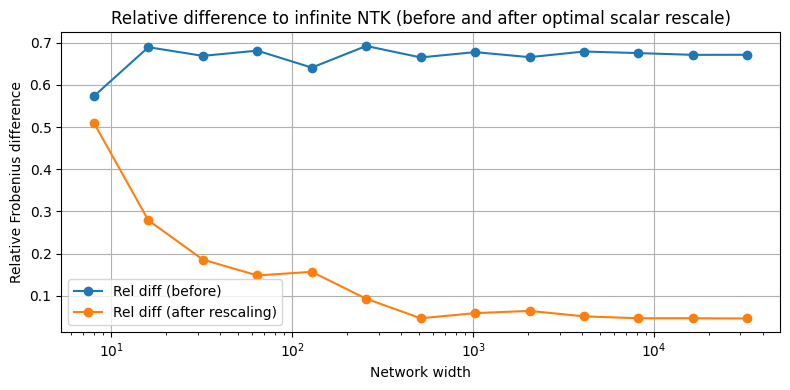

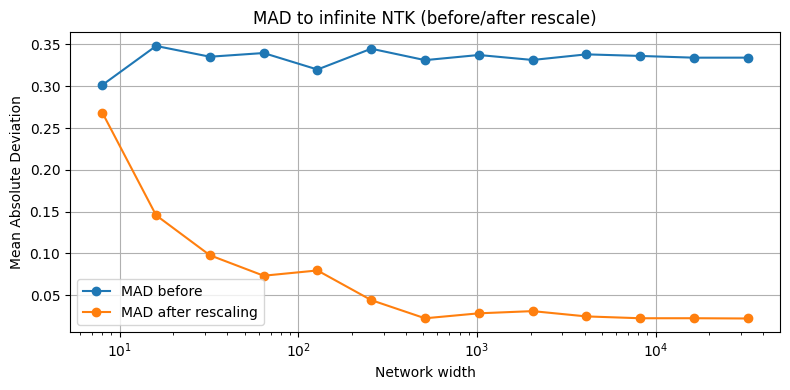

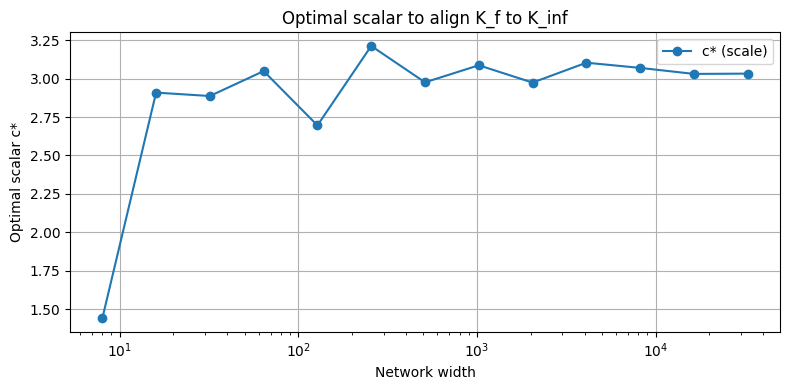

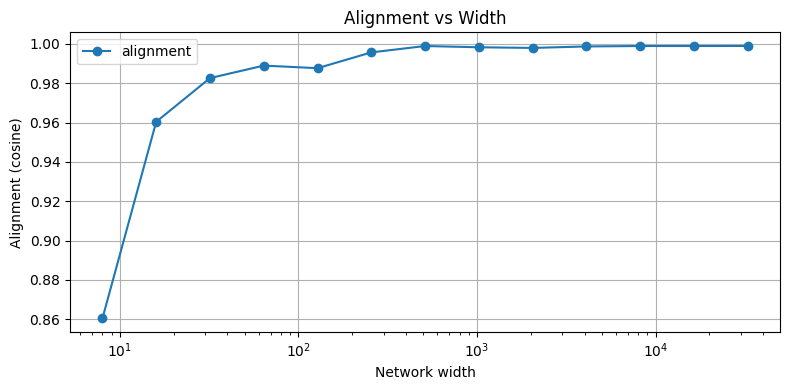

In [17]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# assume:
# widths: list of widths
# Ks_train_train_dict: dict width -> empirical kernel (shape matches K_ref)
# K_ref: K_train_train_inf (same shape as each K_finite)

def flatten(K):
    return K.ravel()

def inner(K1, K2):
    return float(jnp.vdot(flatten(K1), flatten(K2)))  # complex-safe vdot

def frob_norm(K):
    return float(jnp.linalg.norm(K))

# Collect metrics
rels_before = []
rels_after = []
mads_before = []
mads_after = []
scales = []
aligns = []

for w in widths:
    Kf = Ks_train_train_dict[w]
    Ki = K_ref

    # alignment (cosine)
    dot = inner(Kf, Ki)
    norm_f = frob_norm(Kf)
    norm_i = frob_norm(Ki)
    alignment = dot / (norm_f * norm_i + 1e-12)
    aligns.append(alignment)

    # relative difference before (‖Kf - Ki‖ / ‖Ki‖)
    rel_before = float(jnp.linalg.norm(Kf - Ki) / (norm_i + 1e-12))
    rels_before.append(rel_before)

    # MAD before
    mad_b = float(jnp.mean(jnp.abs(Kf - Ki)))
    mads_before.append(mad_b)

    # optimal scalar c* = <Kf, Ki> / <Kf, Kf>
    denom = inner(Kf, Kf) + 1e-12
    c_opt = dot / denom
    scales.append(c_opt)

    # rescale and recompute
    Kf_scaled = c_opt * Kf
    rel_after = float(jnp.linalg.norm(Kf_scaled - Ki) / (norm_i + 1e-12))
    rels_after.append(rel_after)

    mad_a = float(jnp.mean(jnp.abs(Kf_scaled - Ki)))
    mads_after.append(mad_a)

# Plot relative difference before/after
plt.figure(figsize=(8,4))
plt.plot(widths, rels_before, marker='o', label='Rel diff (before)')
plt.plot(widths, rels_after, marker='o', label='Rel diff (after rescaling)')
plt.xscale('log')
plt.xlabel('Network width')
plt.ylabel('Relative Frobenius difference')
plt.title('Relative difference to infinite NTK (before and after optimal scalar rescale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot MAD before/after
plt.figure(figsize=(8,4))
plt.plot(widths, mads_before, marker='o', label='MAD before')
plt.plot(widths, mads_after, marker='o', label='MAD after rescaling')
plt.xscale('log')
plt.xlabel('Network width')
plt.ylabel('Mean Absolute Deviation')
plt.title('MAD to infinite NTK (before/after rescale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot scale factors and alignments
plt.figure(figsize=(8,4))
plt.plot(widths, scales, marker='o', label='c* (scale)')
plt.xscale('log')
plt.xlabel('Network width')
plt.ylabel('Optimal scalar c*')
plt.title('Optimal scalar to align K_f to K_inf')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(widths, aligns, marker='o', label='alignment')
plt.xscale('log')
plt.xlabel('Network width')
plt.ylabel('Alignment (cosine)')
plt.title('Alignment vs Width')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
